[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb02_llm_regimes_and_memory.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb02 — Does the LLM read regimes, or remember them?

**Question.** nb01 set the bar: no no-LLM forecaster beats uniform on Brier (0.750). Here Claude Sonnet 5.5 forecasts the same months, and the issue is whether a good score would come from reading the data or from remembering what happened next, since the model was trained on text that covers the whole sample. The notebook audits contamination, blinds the data, and tests the fix. Every answer is replayed from the committed cache (`results/llm_cache/`): no API calls, nothing fitted beyond the baselines in `results/baselines/`.

## Setup

**Task.** At each month-end $t$ (2007-12 → 2026-05) the model reads a point-in-time snapshot and returns probabilities $p_{t,k}$ for the regime of the next three months; 217 of the 222 months have a realised outcome. Regimes, uniform control and baselines are those of nb01.

**Prompt variants** (same model, same months). *Raw snapshot* ("raw pack" in tables): levels, 3- and 12-month changes and 36-month z-scores, labelled by role; no date, no tickers. *Raw + date* adds the as-of date; *date only* gives the date and no data. The *date-recovery probe* gives the raw snapshot and asks only which month it is. The *blinded snapshot* replaces every figure by
$$z_t=\frac{x_t-\bar x_{t-35:t}}{s_{t-35:t}},$$
where $\bar x_{t-35:t}$ and $s_{t-35:t}$ are the mean and standard deviation of the series' own last 36 monthly values (month $t$ included, at least 12 required), rounded to the nearest 0.5 and capped at ±3. Only trailing data are used; a unit test checks point-in-time invariance.

**Scores.** Hit rate, Brier $=\frac1N\sum_t\sum_k(p_{t,k}-y_{t,k})^2$ (uniform = 0.750) and log-loss (uniform = 1.386). Confidence intervals are 95% moving-block bootstraps (6-month blocks) of the paired per-month difference.

**Order.** First look → give it the date → can it date the snapshot? → blind → verdict on the months it cannot date → robustness.

In [2]:
import sys, json, glob
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import R, score, brier_per_obs, block_bootstrap_ci, uniform, hard
from lra.llm.blind import blind_features
from lra.llm.prompts import render_data, render_blinded
B, L = Path('../results/baselines'), Path('../results/llm')
# regimes (separate from the model colours used in nb02-nb05 figures): Goldilocks, Reflation, Stagflation, Risk_Off
C = ['#7e57c2', '#e0559c', '#8d6e3f', '#1f3a5f']
SON = '#2a78d6'                         # Sonnet; GPT #eb6834, Gemini #1baf7a, GLM #eda100 (nb04-nb05); ML and baselines are greys
GREY = {'uniform': '#0b0b0b', 'climatology': '#b5b4ae', 'ml_logit': '#8a8984', 'ml_gbt': '#b5b4ae'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})

def fmt(df, pct=(), d0=(), d1=(), d2=()):
    """Display only: Sharpe 2 decimals, Brier 3, percentages 0 (stored results are untouched)."""
    f = {**{c: '{:.0%}' for c in pct}, **{c: '{:.0f}' for c in d0}, **{c: '{:.1f}' for c in d1}, **{c: '{:.2f}' for c in d2}}
    return df.style.format(f, precision=3, na_rep='–')
rd = lambda p: pd.read_csv(p, parse_dates=['date'], index_col='date')
reg, fair, feat = rd(B / 'regimes.csv'), rd(B / 'regimes_fair.csv'), rd(B / 'features.csv')
y = reg['realised_forward'].dropna()
son = {v: rd(L / f'claude_sonnet/{v}_run0.csv') for v in ('anonymized', 'dated', 'date_only', 'blinded')}
probe = {k: rd(L / f'claude_sonnet/{k}_run0.csv') for k in ('date_probe', 'date_probe_blinded')}
cols = lambda df, p: df[[f'{p}_{k}' for k in R]].set_axis(R, axis=1)
fc = {'uniform 25%': uniform(reg.index),
      'climatology (point-in-time)': cols(fair, 'climatology'),
      'rule (persistence)': hard(reg['rule']),
      'ML logit, raw pack': cols(reg, 'logit'), 'ML GBT, raw pack': cols(reg, 'gbt'),
      'ML logit, blinded pack': cols(fair, 'logit_blinded'), 'ML GBT, blinded pack': cols(fair, 'gbt_blinded'),
      'Haiku 4.5, raw pack': rd(L / 'claude_haiku/anonymized_run0.csv')[R],
      'Llama 3.1 8B, raw pack': rd(L / 'llama8b/anonymized_run0.csv')[R],
      'Sonnet 5.5, raw pack': son['anonymized'][R], 'Sonnet 5.5, raw pack + date': son['dated'][R],
      'Sonnet 5.5, date only': son['date_only'][R], 'Sonnet 5.5, blinded pack': son['blinded'][R]}
def table(names, idx=y.index):
    yy = y.loc[idx]
    t = pd.DataFrame({n: score(fc[n], yy) for n in names}).T
    return t.astype({'n': int})

## 1. First look: the raw snapshot, no date, no tickers

The prompt holds the latest published macro values and asset-class returns, labelled by role ("US large-cap equity"), never by ticker or date.

In [3]:
fmt(table(['uniform 25%', 'climatology (point-in-time)', 'rule (persistence)', 'ML logit, raw pack', 'ML GBT, raw pack',
           'Haiku 4.5, raw pack', 'Llama 3.1 8B, raw pack', 'Sonnet 5.5, raw pack']), pct=['hit_rate'])

,n,hit_rate,brier,log_loss
uniform 25%,217,19%,0.750,1.386
climatology (point-in-time),217,16%,0.770,1.427
rule (persistence),217,33%,1.099,2.056
"ML logit, raw pack",217,37%,0.861,1.761
"ML GBT, raw pack",217,32%,0.880,1.730
"Haiku 4.5, raw pack",217,24%,0.864,1.572
"Llama 3.1 8B, raw pack",217,24%,0.874,1.681
"Sonnet 5.5, raw pack",217,37%,0.702,1.324


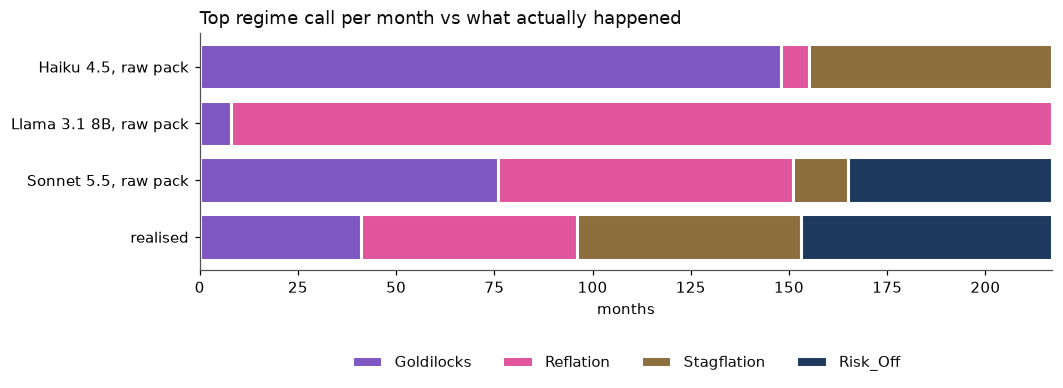

,Goldilocks,Reflation,Stagflation,Risk_Off
"Haiku 4.5, raw pack",148,7,62,0
"Llama 3.1 8B, raw pack",8,209,0,0
"Sonnet 5.5, raw pack",76,75,14,52
realised,41,55,57,64


In [4]:
calls = pd.DataFrame({m: fc[m].loc[y.index].idxmax(axis=1).value_counts() for m in
                      ['Haiku 4.5, raw pack', 'Llama 3.1 8B, raw pack', 'Sonnet 5.5, raw pack']}).T
calls.loc['realised'] = y.value_counts()
calls = calls[R].fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 2.8))
left = np.zeros(len(calls))
for k, c in zip(R, C):
    ax.barh(calls.index, calls[k], left=left, color=c, label=k, edgecolor='white', linewidth=2)
    left += calls[k].values
ax.invert_yaxis(); ax.grid(False); ax.set_xlabel('months')
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.3))
ax.set_title('Top regime call per month vs what actually happened', loc='left'); plt.show()
calls

**Reading.** **Key finding:** Sonnet is the only forecaster that beats uniform on Brier (0.702 against 0.750) and log-loss, with a hit rate (37%) level with the best ML model. Haiku and Llama collapse onto one regime (Llama calls Reflation in 209 of 217 months), so they carry no information and Llama cannot serve as the pre-cutoff control we had planned.

In [5]:
d = brier_per_obs(fc['Sonnet 5.5, raw pack'], y) - brier_per_obs(fc['uniform 25%'], y)
print(f'Sonnet raw - uniform Brier: {d.mean():+.3f}  95% CI {np.round(block_bootstrap_ci(d), 3)}')

Sonnet raw - uniform Brier: -0.048  95% CI [-0.111  0.013]


**Reading.** Sonnet's edge over uniform on the raw snapshot is not significant: the interval includes zero.

## 2. Give it the date

Same snapshot plus the as-of date in the prompt (*raw + date*). A second ablation gives only the date and no data (*date only*). If skill comes from reading the data, the date should add nothing.

In [6]:
fmt(table(['uniform 25%', 'Sonnet 5.5, date only', 'Sonnet 5.5, raw pack', 'Sonnet 5.5, raw pack + date']), pct=['hit_rate'])

,n,hit_rate,brier,log_loss
uniform 25%,217,19%,0.750,1.386
"Sonnet 5.5, date only",217,22%,0.747,1.380
"Sonnet 5.5, raw pack",217,37%,0.702,1.324
"Sonnet 5.5, raw pack + date",217,47%,0.651,1.227


dated - raw Brier: -0.051  95% CI [-0.07  -0.036]
date changes the top call in 54 months: dated right 28, raw right 6


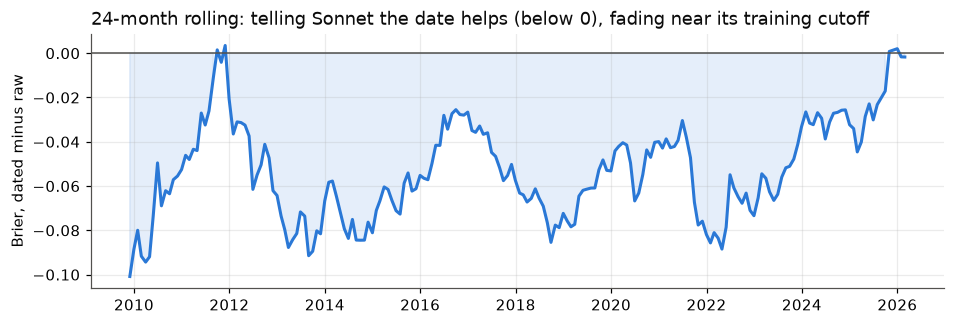

In [7]:
a, d_ = fc['Sonnet 5.5, raw pack'], fc['Sonnet 5.5, raw pack + date']
diff = brier_per_obs(d_, y) - brier_per_obs(a, y)
print(f'dated - raw Brier: {diff.mean():+.3f}  95% CI {np.round(block_bootstrap_ci(diff), 3)}')
ca, cd = a.loc[y.index].idxmax(axis=1), d_.loc[y.index].idxmax(axis=1)
sw = y.index[ca != cd]
print(f'date changes the top call in {len(sw)} months: dated right {(cd[sw] == y[sw]).sum()}, '
      f'raw right {(ca[sw] == y[sw]).sum()}')
roll = diff.rolling(24).mean()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(roll.index, roll, color=SON)
ax.axhline(0, color=MUTED, linewidth=1)
ax.fill_between(roll.index, roll, 0, where=roll < 0, color=SON, alpha=0.12)
ax.set_ylabel('Brier, dated minus raw')
ax.set_title('24-month rolling: telling Sonnet the date helps (below 0), fading near its training cutoff', loc='left')
plt.show()

**Reading.** **Control:** with no data Sonnet declines to guess (Brier 0.747, about uniform), so date-only carries no information. **Key finding:** adding the date to the data lowers Brier by 0.051 (CI [−0.070, −0.036]); where the date changes the top call, the dated call is right in 28 of 54 months and the raw call in 6. The gain is smallest in the last months of the sample, nearest the model's training cutoff, which is consistent with remembered outcomes rather than better reasoning.

## 3. Can it work out the date anyway?

The date-recovery probe gives the raw snapshot, no date, and asks only *which month is this?* (year and month, 2007–2026). `error_months` is the gap between guess and truth.

In [8]:
def probe_stats(p):
    e = p['error_months'].abs()
    return pd.Series({'exact month': (e == 0).mean(), 'within 6m': (e <= 6).mean(),
                      'within 12m': (e <= 12).mean(), 'mean abs error (months)': e.mean()})
pd.DataFrame({'raw pack': probe_stats(probe['date_probe']),
              'blinded pack': probe_stats(probe['date_probe_blinded'])}).style.format(
    '{:.0%}', subset=pd.IndexSlice[['exact month', 'within 6m', 'within 12m'], :]).format(
    '{:.1f}', subset=pd.IndexSlice[['mean abs error (months)'], :])

,raw pack,blinded pack
exact month,84%,14%
within 6m,100%,38%
within 12m,100%,50%
mean abs error (months),0.2,45.5


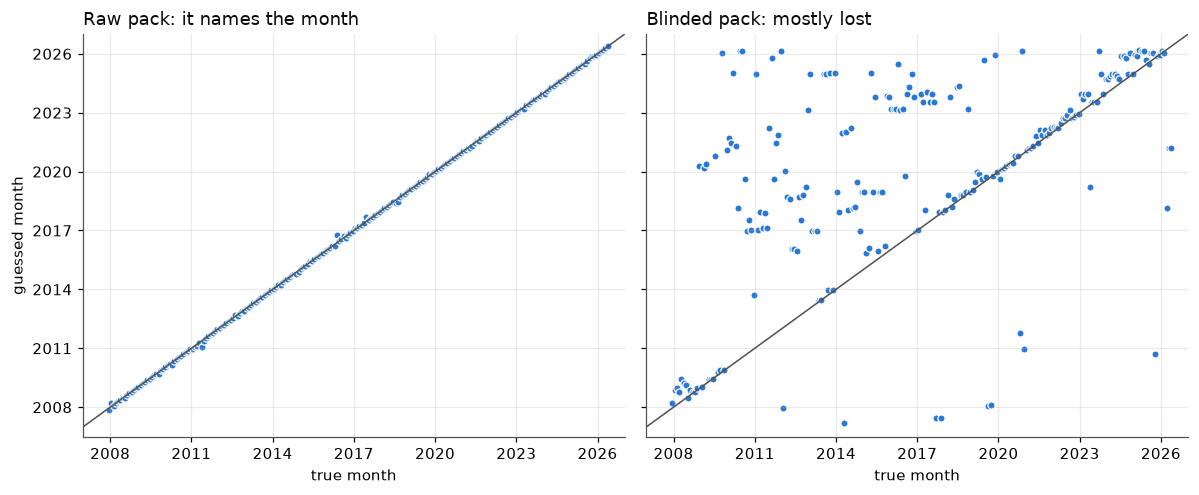

In [9]:
def to_year(idx, yr, mo): return yr + (mo - 0.5) / 12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, (k, title), c in zip(axes, [('date_probe', 'Raw pack: it names the month'),
                                    ('date_probe_blinded', 'Blinded pack: mostly lost')], [SON, SON]):
    p = probe[k]
    t = p.index.year + (p.index.month - 0.5) / 12
    g = to_year(p.index, p['guess_year'], p['guess_month'])
    ax.plot([2007, 2027], [2007, 2027], color=MUTED, linewidth=1)
    ax.scatter(t, g, s=22, color=c, edgecolor='white', linewidth=0.8)
    ax.set_xlim(2007, 2027); ax.set_ylim(2006.5, 2027); ax.set_title(title, loc='left')
    ax.set_xticks(range(2008, 2027, 3)); ax.set_yticks(range(2008, 2027, 3))
    ax.set_xlabel('true month')
axes[0].set_ylabel('guessed month'); plt.tight_layout(); plt.show()

In [10]:
rec = next(json.load(open(f)) for f in glob.glob('../results/llm_cache/claude-sonnet-5-5/*/*.json')
           if (r := json.load(open(f))).get('variant') == 'date_probe' and r['decision_date'] == '2013-05-31')
print(json.loads(rec['text'][rec['text'].find('{'):])['cues'])

['Unemployment 7.5% and 10-year yield 2.13% after a sharp rise, consistent with the 2013 taper tantrum', 'Gold down about 12% over 3 months and 20+ year Treasuries -7.7% in one month', 'Headline CPI about 1.1% YoY and US equities near highs with VIX about 14.5']


**Reading.** **Key finding:** removing the date and tickers did not anonymise anything. From levels such as the policy rate, the 10-year yield and unemployment, Sonnet names the exact month in 84% of months and is within six months in all of them (the 2013-05 cues are the taper tantrum, gold's fall and CPI near 1%). The raw-snapshot result in section 1 is therefore not clean: the model knew where it was.

## 4. Blind the snapshot

Every figure becomes the trailing z-score defined in Setup: no levels, no percentages. The economics survive ("inflation high and rising against its recent past, bonds selling off"); the timestamp should not. Same month, before and after:

In [11]:
d0 = pd.Timestamp('2013-05-31')
raw_lines = render_data(feat.loc[d0]).splitlines()
bl_lines = render_blinded(blind_features(feat).loc[d0]).splitlines()
keep = ('indicator |', 'asset |', 'Unemployment rate', '10-year Treasury yield', 'Headline CPI', 'US Treasuries 20y+', 'Gold')
pick = lambda lines: '\n'.join(l for l in lines if l.startswith(keep))
print('RAW (excerpt)'); print(pick(raw_lines))
print('\nBLINDED (excerpt)'); print(pick(bl_lines))

RAW (excerpt)
indicator | units | latest | 3m chg | 12m chg | z
Unemployment rate | % | +7.50 | -0.40 | -0.60 | -1.69
Headline CPI | YoY % | +1.11 | -0.47 | -1.16 | -1.23
10-year Treasury yield | % | +2.13 | +0.24 | +0.54 | -0.29
asset | 1m | 3m | 6m | 12m | vol 6m | drawdown 12m
US Treasuries 20y+ | -7.7% | -3.3% | -7.3% | -4.6% | +12.7% | -11.5%
Gold | -5.1% | -12.1% | -19.6% | -11.3% | +20.1% | -22.9%

BLINDED (excerpt)
indicator | level | 3m change | 12m change
Unemployment rate | -1.5 | -1.0 | +0.0
Headline CPI | -1.0 | -0.5 | -1.0
10-year Treasury yield | -0.5 | +1.0 | +2.0
asset | 1m | 3m | 6m | 12m | vol 6m | drawdown 12m
US Treasuries 20y+ | -2.0 | -1.0 | -1.0 | -1.5 | -1.0 | -1.5
Gold | -1.0 | -2.0 | -2.5 | -1.5 | +0.5 | -2.5


In [12]:
p = probe['date_probe_blinded']
e = p['error_months'].abs()
by = e.groupby(pd.cut(p.index.year, [2006, 2012, 2019, 2026], labels=['2007-12', '2013-19', '2020-26']), observed=True)
fmt(pd.DataFrame({'months': by.size(), 'mean abs error': by.mean(), 'within 6m': by.apply(lambda s: (s <= 6).mean())}), pct=['within 6m'], d1=['mean abs error'])

,months,mean abs error,within 6m
2007-12,61,74.2,21%
2013-19,84,53.9,27%
2020-26,77,13.8,62%


**Reading.** **Key finding:** blinding removes most of the date signal: the exact month is named in 14% of months (84% raw), and the 2007–2012 months are mostly lost (mean error 74 months). The recent period (COVID, the 2022 inflation shock) stays recognisable even as z-scores (62% within six months). Rather than blind harder, the probe splits the months: those Sonnet cannot date (more than 12 months off) are the cleaner test.

## 5. Verdict: the blinded snapshot

Sonnet on the blinded snapshot against no-LLM forecasters that see **exactly the same information** (walk-forward logit and GBT on the blinded features) and against the no-skill baselines, on all months and split by whether Sonnet can date the month.

In [13]:
names = ['uniform 25%', 'climatology (point-in-time)', 'ML logit, blinded pack', 'ML GBT, blinded pack',
         'Sonnet 5.5, raw pack', 'Sonnet 5.5, blinded pack', 'Sonnet 5.5, raw pack + date']
err = probe['date_probe_blinded']['error_months'].loc[y.index].abs()
groups = {'all months': y.index, 'cannot date (>12m off)': y.index[err > 12], 'can date (≤12m)': y.index[err <= 12]}
tb = pd.concat({g: table(names, idx)['brier'] for g, idx in groups.items()}, axis=1)
tb.loc['months (n)'] = [len(i) for i in groups.values()]
fmt(tb.rename_axis('Brier (lower is better)')).format('{:.0f}', subset=pd.IndexSlice[['months (n)'], :])

,all months,cannot date (>12m off),can date (≤12m)
Brier (lower is better),,,
uniform 25%,0.750,0.750,0.750
climatology (point-in-time),0.770,0.773,0.767
"ML logit, blinded pack",0.884,0.914,0.854
"ML GBT, blinded pack",0.871,0.954,0.786
"Sonnet 5.5, raw pack",0.702,0.725,0.678
"Sonnet 5.5, blinded pack",0.668,0.699,0.637
"Sonnet 5.5, raw pack + date",0.651,0.678,0.623
months (n),217,109,108


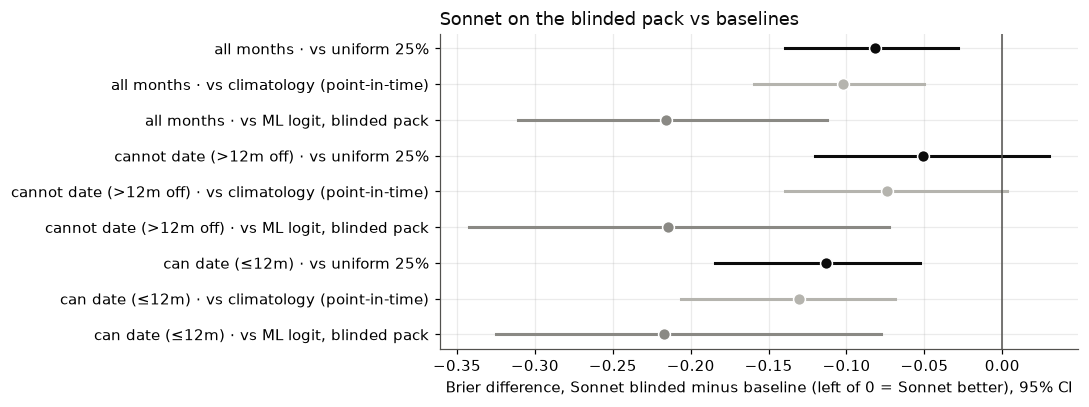

,months,vs,n,diff,lo,hi
0,all months,uniform 25%,217,-0.082,-0.139,-0.028
1,all months,climatology (point-in-time),217,-0.102,-0.159,-0.051
2,all months,"ML logit, blinded pack",217,-0.216,-0.311,-0.113
3,cannot date (>12m off),uniform 25%,109,-0.051,-0.120,0.030
4,cannot date (>12m off),climatology (point-in-time),109,-0.074,-0.139,0.003
5,cannot date (>12m off),"ML logit, blinded pack",109,-0.215,-0.342,-0.072
6,can date (≤12m),uniform 25%,108,-0.113,-0.185,-0.053
7,can date (≤12m),climatology (point-in-time),108,-0.130,-0.206,-0.069
8,can date (≤12m),"ML logit, blinded pack",108,-0.217,-0.325,-0.078


In [14]:
rows = []
for g, idx in groups.items():
    yy = y.loc[idx]
    for ref in ['uniform 25%', 'climatology (point-in-time)', 'ML logit, blinded pack']:
        dd = (brier_per_obs(fc['Sonnet 5.5, blinded pack'], yy) - brier_per_obs(fc[ref], yy)).reset_index(drop=True)
        lo, hi = block_bootstrap_ci(dd)
        rows.append({'months': g, 'vs': ref, 'n': len(yy), 'diff': dd.mean(), 'lo': lo, 'hi': hi})
ci = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 3.8))
ypos = np.arange(len(ci))[::-1]
colors = {'uniform 25%': GREY['uniform'], 'climatology (point-in-time)': GREY['climatology'], 'ML logit, blinded pack': GREY['ml_logit']}
for yp, (_, r) in zip(ypos, ci.iterrows()):
    ax.plot([r.lo, r.hi], [yp, yp], color=colors[r.vs], linewidth=2)
    ax.scatter(r['diff'], yp, s=60, color=colors[r.vs], edgecolor='white', zorder=3)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_yticks(ypos, [f"{r.months} · vs {r.vs}" for _, r in ci.iterrows()])
ax.set_xlabel('Brier difference, Sonnet blinded minus baseline (left of 0 = Sonnet better), 95% CI')
ax.set_title('Sonnet on the blinded pack vs baselines', loc='left'); plt.tight_layout(); plt.show()
fmt(ci)

**Reading.** **Key finding:** on the blinded snapshot Sonnet scores a Brier of 0.668, better than uniform by 0.082 (CI [−0.139, −0.028]) and better than ML on the same inputs (0.884 logit, 0.871 GBT). **Control:** in the months it cannot date the edge over ML holds (CI excludes zero) while the intervals against uniform and climatology touch zero (upper bounds 0.030 and 0.003).

## 6. Robustness checks

Added after an external adversarial review. **(a) Is "cannot date" just a period split?** The months Sonnet cannot date are mostly 2008–2019, the others mostly 2020 onward. Compare within the same era, then with year fixed effects:

In [15]:
fmt(pd.read_csv('../results/h1/date_probe_era.csv'))

,era,bucket,n,brier_minus_uniform,ci_lo,ci_hi
0,2007-2019,can date,47,-0.139,–,–
1,2007-2019,cannot date,98,-0.047,–,–
2,2020-2026,can date,61,-0.094,–,–
3,2020-2026,cannot date,11,-0.085,–,–
4,"all, year fixed effects",datable minus cannot-date,217,0.037,-0.076,0.134


**Reading.** Within 2007–2019 the datable months show the larger gain over uniform (−0.139 against −0.047), but comparing months within the same year the difference disappears (+0.037, CI [−0.076, 0.134]). The split cannot separate memory from period and regime difficulty: it is evidence, not proof, that the edge does not depend on recall.

**(b) Which vintage scores the outcome?** The primary target uses the data-end vintage. Scoring each month with the first release that makes its regime knowable changes 33 of 217 labels:

In [16]:
sc = pd.read_csv('../results/h1/scores.csv')
keep = ['uniform', 'climatology', 'ml_logit', 'ml_logit_blinded', 'claude_sonnet:anonymized',
        'claude_sonnet:blinded', 'claude_sonnet:dated']
sc[sc.forecaster.isin(keep) & sc.window.isin(['full', 'first-release labels'])]\
  .pivot(index='forecaster', columns='window', values='brier').loc[keep].pipe(fmt)

window,first-release labels,full
forecaster,,
uniform,0.750,0.750
climatology,0.765,0.770
ml_logit,0.822,0.861
ml_logit_blinded,0.854,0.884
claude_sonnet:anonymized,0.669,0.702
claude_sonnet:blinded,0.646,0.668
claude_sonnet:dated,0.627,0.651


**Reading.** Every forecaster scores slightly better on first-release labels and the ranking is unchanged.

**(c) CFNAI before 2011-05 uses revised values** (its ALFRED vintages start then). Revisions are moderate (3-month average: mean absolute revision 0.18 against a standard deviation of 0.78, correlation 0.94); the broad dollar index, hybrid until 2019, revises negligibly (year-on-year: 0.17 pp against 6 pp). Dropping CFNAI leaves the ML baselines essentially unchanged:

In [17]:
sc[sc.forecaster.isin(['ml_logit', 'ml_logit_nocfnai', 'ml_logit_blinded', 'ml_logit_blinded_nocfnai']) &
   (sc.window == 'full')][['forecaster', 'hit_rate', 'brier', 'log_loss']].pipe(fmt, pct=['hit_rate'])

,forecaster,hit_rate,brier,log_loss
4,ml_logit,37%,0.861,1.761
8,ml_logit_blinded,30%,0.884,1.708
14,ml_logit_nocfnai,37%,0.859,1.742
16,ml_logit_blinded_nocfnai,33%,0.882,1.716


For Sonnet, the 41 affected months (2007-12 → 2011-04) were re-asked without the CFNAI line (`blinded_nocfnai`, 41 calls):

In [18]:
fmt(pd.read_csv('../results/h1/nocfnai_check.csv'), pct=['hit_rate'])

,forecaster,n,hit_rate,brier,log_loss,ci_lo,ci_hi
0,"blinded, 2007-12..2011-04",41,49%,0.599,1.094,–,–
1,"blinded without CFNAI, 2007-12..2011-04",41,46%,0.622,1.145,–,–
2,"uniform, 2007-12..2011-04",41,17%,0.750,1.386,–,–
3,"blinded, full sample",217,46%,0.668,1.244,–,–
4,"blinded with CFNAI-free months spliced in, full sample",217,45%,0.672,1.254,–,–
5,difference: without minus with CFNAI (Brier),41,–,0.023,–,0.003,0.046


**Reading.** **Control:** without CFNAI Sonnet is slightly but measurably worse in those months (Brier +0.023, CI [0.003, 0.046]) and still far better than uniform, keeping the same top call in 93% of them. Removing the line removes CFNAI's information as well as its revisions, and the model is not deterministic, so this bounds the revision effect rather than isolating it. Splicing the CFNAI-free months into the full sample moves Brier from 0.668 to 0.672.

## What we can and cannot claim

- **Contamination is real.** Sonnet 5.5 names the exact month of a date-free, ticker-free raw snapshot in 84% of months, and telling it the date lowers Brier by 0.051 (CI excludes zero). Raw-snapshot backtests of LLM forecasters are not out-of-sample; nb04 finds the same for GPT on the blinded snapshot.
- **Blinding lowers the date signal without hurting the forecasts.** On z-scores Sonnet scores better than on raw levels (paired CI excludes zero; not displayed here) and better than uniform over the full sample.
- **The edge persists in the months it cannot date** and beats ML on identical inputs there; against uniform and climatology the intervals touch zero. Because those months are mostly 2008–2019, this does not rule memory out (section 6a).
- **This backtest is exploratory.** The blinded snapshot was designed after the raw snapshot failed the date probe, on the same 18-year path.
- **Not claimed:** that the model cannot recognise blinded months (in the recent period it can) or that the historical edge is skill. One run per variant at provider defaults; run-to-run variance and other model families are examined in nb04.

## Next

nb03 turns these probabilities (blinded Sonnet and the baselines) into portfolios and asks whether the forecasting edge survives allocation and costs.